# 06. Surface temperature

Air temperature is one number for the whole city. The ground is not. On the 43 °C January day
modelled here, the open road ends up near 70 °C by mid-afternoon, a lawn 13 °C below that,
and a shaded laneway below air temperature — same sky, same hour.

Here that number gets worked out for every cell: one equation, six terms, marched hour by
hour. Out come `tsurf_06..20.npy`, which is what 07 turns into what a body feels.

In [40]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
CELL = CONFIG["cell_size"]
DATE = CONFIG["date"]

# The same 1500 x 1500 window over the CBD that 03 marched. Full grid once, at the end.
half = int(3000 / CELL / 2)
CROP = np.s_[H // 2 - half:H // 2 + half, W // 2 - half:W // 2 + half]

print(f"grid  {W} x {H}   crop  {2 * half} x {2 * half} cells   {DATE}")

grid  2438 x 2485   crop  1500 x 1500 cells   2026-01-27


In [41]:
HOURS = list(range(6, 21))

shade = {h: np.load(f"out/rasters/shade_{h:02d}.npy")[CROP] for h in HOURS}   # True = in shadow
svf   = np.load("out/rasters/svf_veg.npy")[CROP]
mat   = np.load("out/rasters/material_id.npy")[CROP]
dsm   = np.load("out/rasters/dsm_buildings.npy")[CROP]

props   = json.load(open("out/material_props.json"))
CLASSES = props["classes"]

ALBEDO = np.array([props["props"][c]["albedo"] for c in CLASSES])   # indexed by the id in mat
EMIS   = np.array([props["props"][c]["emis"]   for c in CLASSES])
HEAT   = np.array([props["props"][c]["heat"]   for c in CLASSES])

print(f"shaded at 14:00  {shade[14].mean() * 100:.0f}%      mean SVF  {svf.mean():.2f}")

shaded at 14:00  54%      mean SVF  0.67


In [42]:
wx = json.load(open(f"data/weather_{DATE}.json"))

w = pd.DataFrame(wx["hourly"])
w.index = pd.to_datetime(w.pop("time")).dt.hour
w.index.name = "hour"
w["wind_ms"] = w["wind_speed_10m"] / 3.6         # km/h -> m/s, the conversion 04 flagged

COLS = ["temperature_2m", "relative_humidity_2m", "direct_radiation",
        "diffuse_radiation", "wind_ms", "cloud_cover"]
print(w.loc[HOURS, COLS].round(1).to_string())

      temperature_2m  relative_humidity_2m  direct_radiation  diffuse_radiation  wind_ms  cloud_cover
hour                                                                                                 
6               15.7                    85               4.0                6.0      0.8            0
7               17.6                    73              91.0               49.0      1.0            0
8               21.3                    56             270.0               77.0      1.8            0
9               27.8                    38             465.0               92.0      2.0            0
10              33.2                    28             643.0              102.0      3.8            0
11              36.8                    22             780.0              108.0      4.9            1
12              39.0                    18             867.0              111.0      5.3            2
13              40.8                    16             896.0              113.0   

## One equation

A patch of ground gains heat from the sun and from the sky, and loses it three ways: it
glows, the wind peels heat off it, and whatever is left soaks down into the slab.

$$(1-\alpha)\,K_\downarrow \;+\; L_\downarrow \;-\; L_\uparrow \;-\; H \;=\; \Delta S$$

| term | what it is |
|---|---|
| $(1-\alpha)K_\downarrow$ | sunlight that lands and is not bounced straight back |
| $L_\downarrow$ | infrared coming down off the sky and the walls |
| $L_\uparrow$ | infrared the surface radiates away |
| $H$ | heat the air carries off |
| $\Delta S$ | the leftover, which goes into the ground and comes back later |

All five are W/m². The rest of the notebook is those terms — once for one cell, then for two
million.

### Four cells, before the whole grid

Sampling one square metre at a time, working through four different cells with with a hypothesis before running the code on the full grid

| cell | what it is | what it should do |
|---|---|---|
| open road | asphalt, sky above it, in full sun at 14:00 | the hottest thing here dark, dry, no shade fully open |
| shaded road | the same asphalt, with a building in the beam | much cooler, but still carrying heat it took on this morning |
| park lawn | grass, also in full sun | cool anyway, because it spends its sunlight evaporating water |
| laneway | bluestone, walls both sides, 3% sky | no sun at all, and walls glowing at it from every side |

In [43]:
from pyproj import Transformer

to_m = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)
R0, C0 = CROP[0].start, CROP[1].start                  # the crop's top-left, in full-grid cells

def cell_of(lon, lat):
    x, y = to_m.transform(lon, lat)
    return (int((CONFIG["grid"]["maxy"] - y) / CELL) - R0,
            int((x - CONFIG["grid"]["minx"]) / CELL) - C0)

SPOTS = {"open road":   cell_of(144.97043, -37.81696),
         "shaded road": cell_of(144.96670, -37.81319),
         "park lawn":   cell_of(144.97238, -37.82049),
         "laneway":     cell_of(144.96541, -37.81279)}

HOUR = 14

print(f"{'':13s} {'surface':10s} {'albedo':>7s} {'emis':>6s} {'SVF':>6s} {'at 14:00':>9s}")
for name, (r, c) in SPOTS.items():
    m = mat[r, c]
    print(f"{name:13s} {CLASSES[m]:10s} {ALBEDO[m]:7.2f} {EMIS[m]:6.2f} {svf[r, c]:6.2f}"
          f" {'shaded' if shade[HOUR][r, c] else 'sunlit':>9s}")

              surface     albedo   emis    SVF  at 14:00
open road     asphalt       0.12   0.94   0.82    sunlit
shaded road   asphalt       0.12   0.94   0.49    shaded
park lawn     grass         0.23   0.97   0.89    sunlit
laneway       bluestone     0.15   0.95   0.03    shaded


### $K_\downarrow$ — the sunlight that sticks

Light arrives two ways and the maps decide who gets it. The **direct** beam $K_{dir}$ is paired with  a binary $\text{sunlit}$ already worked out in 01 and 02 which cells are in shadow. **Diffuse** light $K_{dif}$ comes off the whole sky, so a cell gets the share of sky it can see, which is the SVF calculated in 03.

$$K_\downarrow \;=\; K_{dir}\cdot(\text{sunlit}) \;+\; K_{dif}\cdot\text{SVF}$$

Then the surface bounces $\alpha$ of it straight back off, and keeps the rest.
$$K_{abs} \;=\; (1-\alpha)\,K_\downarrow$$

In [44]:
hw = w.loc[HOUR]
Ta, RH, wind = hw["temperature_2m"], hw["relative_humidity_2m"], hw["wind_ms"]
K_dir, K_dif = hw["direct_radiation"], hw["diffuse_radiation"]
cloud = hw["cloud_cover"] / 100

print(f"14:00   air {Ta:.1f} C   RH {RH:.0f}%   wind {wind:.1f} m/s"
      f"   direct {K_dir:.0f}   diffuse {K_dif:.0f} W/m2\n")

print(f"{'':13s} {'K_down':>8s} {'K_absorbed':>11s}")
for name, (r, c) in SPOTS.items():
    K = K_dir * (not shade[HOUR][r, c]) + K_dif * svf[r, c]
    print(f"{name:13s} {K:8.0f} {(1 - ALBEDO[mat[r, c]]) * K:11.0f}")

14:00   air 42.4 C   RH 14%   wind 4.4 m/s   direct 868   diffuse 111 W/m2

                K_down  K_absorbed
open road          959         844
shaded road         54          48
park lawn          967         744
laneway              4           3


### $L_\downarrow$ and $L_\uparrow$ — the glow

Warm things glow. Not visibly at street temperatures, but in infrared, and the amount is
$\varepsilon\sigma T^4$ — fourth power, **kelvin only**. These terms are not a
correction to the sunlight; they are the same size as it.

$\varepsilon$ is emissivity, how good a glower a surface is, 0 to 1. Every ground material in
05 sits between 0.92 and 0.98, so all of them are nearly perfect at it.

#### $L_\downarrow$ — what comes down

The cell looks up and sees two things, mixed in the proportion the SVF gives:

$$L_\downarrow = \underbrace{\varepsilon_{sky}\,\sigma T_a^4}_{\text{sky}}\cdot\text{SVF}
\;+\; \underbrace{\varepsilon_{w}\,\sigma T_a^4}_{\text{walls}}\cdot(1-\text{SVF})$$

Walls we take at air temperature. The sky we cannot — a clear dry sky behaves like a surface
far colder than the air sitting under it. That gap is $\varepsilon_{sky}$, the one number in
this notebook that has to be computed rather than looked up: water vapour is what warms the
sky, so it comes out of the humidity, and cloud drags it back toward 1.

In [45]:
SIGMA = 5.670e-8        # Stefan-Boltzmann, W/m2K4
EPS_WALL = 0.90         # a brick-and-glass facade, near enough to any of the ground classes

Ta_K = Ta + 273.15
es = 6.112 * np.exp(17.62 * Ta / (243.12 + Ta))            # saturation vapour pressure, hPa (Magnus)
e  = es * RH / 100

# Brutsaert 1975 for the clear sky. Cloud plugs the cold gaps with something at air
# temperature, so it drags the emissivity toward 1.
eps_clear = 1.24 * (e / Ta_K) ** (1 / 7)
eps_sky   = eps_clear + (1 - eps_clear) * cloud

L_sky  = eps_sky * SIGMA * Ta_K ** 4
L_wall = EPS_WALL * SIGMA * Ta_K ** 4

print(f"vapour pressure {e:5.1f} hPa   ->   clear sky eps {eps_clear:.2f}"
      f"   with {cloud * 100:.0f}% cloud {eps_sky:.2f}\n")
print(f"the sky sends down  {L_sky:5.0f} W/m2")
print(f"a wall sends down   {L_wall:5.0f} W/m2\n")

print(f"{'':13s} {'SVF':>6s} {'L_down':>8s}")
for name, (r, c) in SPOTS.items():
    print(f"{name:13s} {svf[r, c]:6.2f} {L_sky * svf[r, c] + L_wall * (1 - svf[r, c]):8.0f}")

vapour pressure  11.7 hPa   ->   clear sky eps 0.77   with 0% cloud 0.77

the sky sends down    435 W/m2
a wall sends down     506 W/m2

                 SVF   L_down
open road       0.82      448
shaded road     0.49      471
park lawn       0.89      443
laneway         0.03      504


#### $L_\uparrow$ — what goes back up

Its own glow, plus the $(1-\varepsilon)$ share of what came down that it reflects instead of
absorbing:

$$L_\uparrow = \varepsilon\,\sigma T_s^4 \;+\; (1-\varepsilon)\,L_\downarrow$$

$T_s$ is the surface temperature — the thing this whole notebook is trying to find, and the
only unknown in the equation. So nothing here can be worked out until we guess it. Guess
three, and watch how hard the fourth power bites back.

In [46]:
r, c = SPOTS["open road"]
eps = EMIS[mat[r, c]]
L_down = L_sky * svf[r, c] + L_wall * (1 - svf[r, c])

print(f"open road   L_down {L_down:.0f} W/m2   air {Ta:.1f} C\n")
print(f"{'guess Ts':>9s} {'L_up':>8s} {'L_down - L_up':>15s}")
for Ts in (30, 50, 70):
    L_up = eps * SIGMA * (Ts + 273.15) ** 4 + (1 - eps) * L_down
    print(f"{Ts:8.0f}C {L_up:8.0f} {L_down - L_up:15.0f}")

open road   L_down 448 W/m2   air 42.4 C

 guess Ts     L_up   L_down - L_up
      30C      477             -29
      50C      608            -160
      70C      766            -318


### $H$ — the wind taking it away

Air that touches hot ground warms up and gets carried off, and cooler air takes its place.
How fast that happens is down to how hard the wind is scrubbing the surface:

$$H = h_c\,(T_s - T_a) \qquad\qquad h_c = 5.7 + 3.8\,u$$

The sign looks after itself. Ground hotter than the air loses heat this way; ground cooler
than the air — a lawn at breakfast — gains it.

One catch. The wind in the weather file is measured at 10 m in the open. Down at knee
height, between buildings, there is much less of it.

In [47]:
WIND_FACTOR = 0.5           # 10 m wind -> ground level, roughly, from the urban log wind profile

u = wind * WIND_FACTOR
h_c = 5.7 + 3.8 * u         # Watmuff 1977, W/m2K

print(f"wind {wind:.1f} m/s at 10 m  ->  {u:.1f} m/s at the ground     h_c {h_c:.1f} W/m2K")
print(f"air is {Ta:.1f} C\n")

print(f"{'guess Ts':>9s} {'H':>8s}")
for Ts in (30, 50, 70):
    print(f"{Ts:8.0f}C {h_c * (Ts - Ta):8.0f}")

wind 4.4 m/s at 10 m  ->  2.2 m/s at the ground     h_c 14.1 W/m2K
air is 42.4 C

 guess Ts        H
      30C     -175
      50C      107
      70C      389


### $LE$ — the term that makes grass grass

The four terms so far have the lawn absorbing 744 W/m², nearly as much as the road, and
losing it no faster. Run with that and the model puts grass hotter than asphalt, which is
plainly wrong.

What is missing is water. A lawn spends most of its sunlight evaporating rather than heating
up — the energy leaves as vapour and the temperature never sees it. Asphalt and bluestone
have no water to spend, so they have no way out of it.

The crude version, and the one used here: give each surface a fixed share $f$ of its
available energy that goes to water instead of temperature.

$$LE = f\cdot\left[(1-\alpha)K_\downarrow + L_\downarrow - L_\uparrow\right]$$

Real evaporation depends on soil moisture, the plant, and when it last rained — none of
which we have, and 05 knows only that a polygon is `grass`. So one share stands in for every
lawn in the city. A watered one would run cooler than this and a brown January one hotter.

In [48]:
# Share of available energy that goes into evaporating water rather than heating the surface.
# Mid-range values for a watered lawn and open water -- Oke, *Boundary Layer Climates*, ch. 4.
EVAP = {"grass": 0.60, "water": 0.90, "gravel": 0.10}
EVAP_F = np.array([EVAP.get(c, 0.0) for c in CLASSES])

for c in CLASSES:
    print(f"  {c:10s} {EVAP.get(c, 0.0):.2f}")

  asphalt    0.00
  bluestone  0.00
  concrete   0.00
  brick      0.00
  gravel     0.10
  grass      0.60
  water      0.90
  roof       0.00


### $\Delta S$ — whatever is left over

Add the five up and they do not cancel. Whatever is left has nowhere to go but down, into
the slab:

$$\Delta S \;=\; \underbrace{(1-\alpha)K_\downarrow + L_\downarrow}_{\text{in}}
\;-\; \underbrace{L_\uparrow + H + LE}_{\text{out}}$$

Positive and the ground is charging up. Negative and it is paying the heat back. Only when
$\Delta S$ happens to be zero is the surface holding still.

All five in one function, below. And then the catch: three of them need $T_s$, which is the
thing we are trying to find.

In [49]:
def fluxes(Ts, hour, sunlit, sky, m):
    """The five fluxes, W/m2, for a surface at Ts. Scalars or whole rasters, same code."""
    hw = w.loc[hour]
    Ta = hw["temperature_2m"]
    Ta_K = Ta + 273.15

    e = 6.112 * np.exp(17.62 * Ta / (243.12 + Ta)) * hw["relative_humidity_2m"] / 100
    eps_clear = 1.24 * (e / Ta_K) ** (1 / 7)
    eps_sky = eps_clear + (1 - eps_clear) * hw["cloud_cover"] / 100
    L_sky, L_wall = eps_sky * SIGMA * Ta_K ** 4, EPS_WALL * SIGMA * Ta_K ** 4

    K_abs = (1 - ALBEDO[m]) * (hw["direct_radiation"] * sunlit + hw["diffuse_radiation"] * sky)
    L_dn  = L_sky * sky + L_wall * (1 - sky)
    L_up  = EMIS[m] * SIGMA * (Ts + 273.15) ** 4 + (1 - EMIS[m]) * L_dn
    H     = (5.7 + 3.8 * hw["wind_ms"] * WIND_FACTOR) * (Ts - Ta)
    LE    = EVAP_F[m] * np.maximum(K_abs + L_dn - L_up, 0)

    return K_abs, L_dn, L_up, H, LE

## The bit that needs memory

Nothing in the equation hands us $T_s$. What $\Delta S$ gives instead is which way it is
moving — leftover energy going into the slab, and a slab that takes energy warms up by

$$\Delta T_s = \frac{\Delta S \cdot \Delta t}{C}$$

$C$ is the heat store from 05, in J per m² per °C. Water's is 2100 kJ and barely moves all
day. Grass's is 60 kJ and swings with every cloud.

So we never solve for a temperature — we start somewhere reasonable and let the leftover push
it around, five minutes at a time. Which also means the temperature at 14:00 is not a
function of 14:00. It is 13:00's answer plus an hour of leftover, and 13:00 is 12:00's answer
plus an hour, all the way back to dawn. That is the memory, and it is why the hottest hour of
the road is not the sunniest one.

In [50]:
DT = 300                      # 5 minute sub-steps -- short enough that the fourth power can't overshoot
STEPS = 3600 // DT

def march(r, c):
    """Ts through the day for one cell, starting from air temperature at 06:00."""
    m, sky, C = mat[r, c], svf[r, c], HEAT[mat[r, c]]
    Ts = w.loc[HOURS[0], "temperature_2m"]

    out = {}
    for hour in HOURS:
        sunlit = ~shade[hour][r, c]
        for _ in range(STEPS):
            K_abs, L_dn, L_up, H, LE = fluxes(Ts, hour, sunlit, sky, m)
            Ts += (K_abs + L_dn - L_up - H - LE) * DT / C
        out[hour] = Ts
    return out

In [51]:
day = {name: march(r, c) for name, (r, c) in SPOTS.items()}

print(f"{'hour':>4s} {'air':>7s}" + "".join(f"{n:>13s}" for n in day))
for h in HOURS:
    print(f"{h:4d} {w.loc[h, 'temperature_2m']:7.1f}" + "".join(f"{day[n][h]:13.1f}" for n in day))

hour     air    open road  shaded road    park lawn      laneway
   6    15.7         14.7         14.8         12.9         15.2
   7    17.6         16.2         14.9         15.6         15.1
   8    21.3         21.1         16.0         21.8         15.8
   9    27.8         29.4         18.5         30.8         17.6
  10    33.2         39.5         22.5         39.9         20.9
  11    36.8         49.2         26.9         46.5         24.6
  12    39.0         57.2         30.6         50.8         28.1
  13    40.8         63.5         33.5         53.9         30.9
  14    42.4         67.9         35.8         56.0         33.3
  15    43.3         70.2         37.6         56.8         35.2
  16    43.4         70.1         39.1         55.8         36.6
  17    43.4         67.4         40.3         53.2         37.7
  18    42.7         62.3         40.4         49.0         38.3
  19    40.3         53.6         39.7         40.5         38.2
  20    38.7         48.6

## Where the day starts

06:00 gets handed air temperature, which is a guess — nobody has told us what the road was
doing overnight. It fades: the leftover each step is large next to what the slab is holding,
so a few degrees of error at dawn is down to about a third of itself by 09:00 and invisible
by noon. The hours that matter are never the ones we made up.

The four curves below are the four predictions from the top of the notebook, checked.

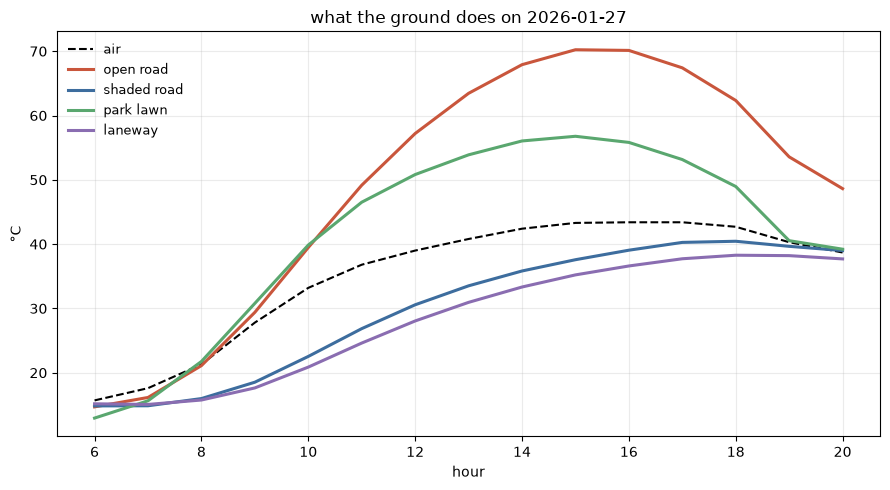

In [52]:
COLOURS = {"open road": "#c9563c", "shaded road": "#3d6d9e",
           "park lawn": "#5aa76f", "laneway": "#8a6db1"}

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(HOURS, [w.loc[h, "temperature_2m"] for h in HOURS], "k--", lw=1.5, label="air")
for name, series in day.items():
    ax.plot(HOURS, [series[h] for h in HOURS], color=COLOURS[name], lw=2.2, label=name)

ax.set_xlabel("hour"); ax.set_ylabel("°C")
ax.set_xticks(list(HOURS)[::2])
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=9)
ax.set_title(f"what the ground does on {DATE}")
fig.tight_layout()

## Back to the six terms, at a temperature we did not make up

The same table, except $T_s$ now comes from the march. Read it as the reason each cell sits
where it does on the plot above — and watch the sign of $H$ in the laneway, which at 33 °C is
colder than the 42 °C air, so the wind is warming it rather than cooling it.

In [53]:
print(f"at 14:00, each cell at the temperature the march put it")
print(f"{'':13s} {'Ts':>6s} {'K_abs':>7s} {'L_down':>7s} {'L_up':>7s} {'H':>7s} {'LE':>7s} {'= dS':>7s}")
for name, (r, c) in SPOTS.items():
    Ts = day[name][HOUR]
    K_abs, L_dn, L_up, H, LE = fluxes(Ts, HOUR, ~shade[HOUR][r, c], svf[r, c], mat[r, c])
    print(f"{name:13s} {Ts:5.1f}C {K_abs:7.0f} {L_dn:7.0f} {L_up:7.0f} {H:7.0f} {LE:7.0f}"
          f" {K_abs + L_dn - L_up - H - LE:7.0f}")

at 14:00, each cell at the temperature the march put it
                  Ts   K_abs  L_down    L_up       H      LE    = dS
open road      67.9C     844     448     748     359       0     185
shaded road    35.8C      48     471     514     -93       0      98
park lawn      56.0C     744     443     659     192     317      19
laneway        33.3C       3     504     500    -128       0     134


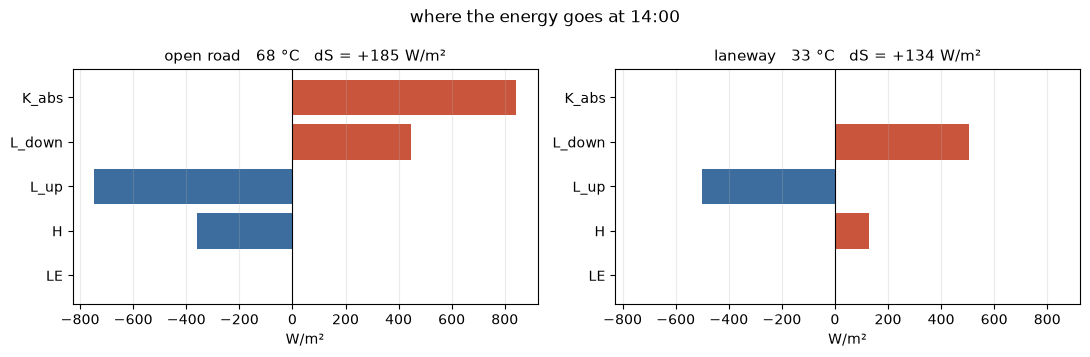

In [54]:
GAIN, LOSS = "#c9563c", "#3d6d9e"
NAMES = ["K_abs", "L_down", "L_up", "H", "LE"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)

for ax, name in zip(axes, ["open road", "laneway"]):
    r, c = SPOTS[name]
    Ts = day[name][HOUR]
    K_abs, L_dn, L_up, H, LE = fluxes(Ts, HOUR, ~shade[HOUR][r, c], svf[r, c], mat[r, c])
    vals = [K_abs, L_dn, -L_up, -H, -LE]

    ax.barh(NAMES, vals, color=[GAIN if v > 0 else LOSS for v in vals])
    ax.axvline(0, color="k", lw=0.8)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("W/m²")
    ax.set_title(f"{name}   {Ts:.0f} °C   dS = {sum(vals):+.0f} W/m²", fontsize=11)

fig.suptitle("where the energy goes at 14:00", fontsize=12)
fig.tight_layout()

## Running the surface temperature across the whole grid

Nothing about the physics changes. `fluxes()` was written to take arrays as happily as it
takes numbers, so the only edit is what goes in: the shade **map** instead of one cell's
`True`, the SVF **raster** instead of one cell's 0.82, the material **ids** instead of one id.

The march is the same too. Every cell starts at dawn air temperature and gets pushed around
by its own leftover, 12 steps an hour, all of them at once.

In [61]:
def march_grid(shade_maps, sky, m):
    """march(), with rasters. Returns {hour: Ts raster}."""
    C = HEAT[m]
    Ts = np.full(sky.shape, w.loc[HOURS[0], "temperature_2m"], np.float32)

    out = {}
    for hour in HOURS:
        sunlit = ~shade_maps[hour]
        for _ in range(STEPS):
            K_abs, L_dn, L_up, H, LE = fluxes(Ts, hour, sunlit, sky, m)
            Ts += ((K_abs + L_dn - L_up - H - LE) * DT / C).astype(np.float32)
        out[hour] = Ts.copy()
    return out

In [62]:
tsurf = march_grid(shade, svf, mat)

ground = dsm <= 0                        # roofs are not a place anyone stands
print(f"{'hour':>4s} {'air':>6s} {'ground mean':>12s} {'hottest':>9s}")
for h in HOURS:
    print(f"{h:4d} {w.loc[h, 'temperature_2m']:6.1f} {tsurf[h][ground].mean():12.1f}"
          f" {tsurf[h][ground].max():9.1f}")

hour    air  ground mean   hottest
   6   15.7         14.6      15.6
   7   17.6         14.9      16.4
   8   21.3         17.2      22.9
   9   27.8         22.1      33.4
  10   33.2         29.0      44.6
  11   36.8         36.5      53.9
  12   39.0         42.7      60.6
  13   40.8         48.0      65.3
  14   42.4         52.3      68.3
  15   43.3         53.8      70.5
  16   43.4         53.5      70.5
  17   43.4         51.8      67.9
  18   42.7         48.8      62.8
  19   40.3         44.5      55.5
  20   38.7         42.0      51.1


## The map

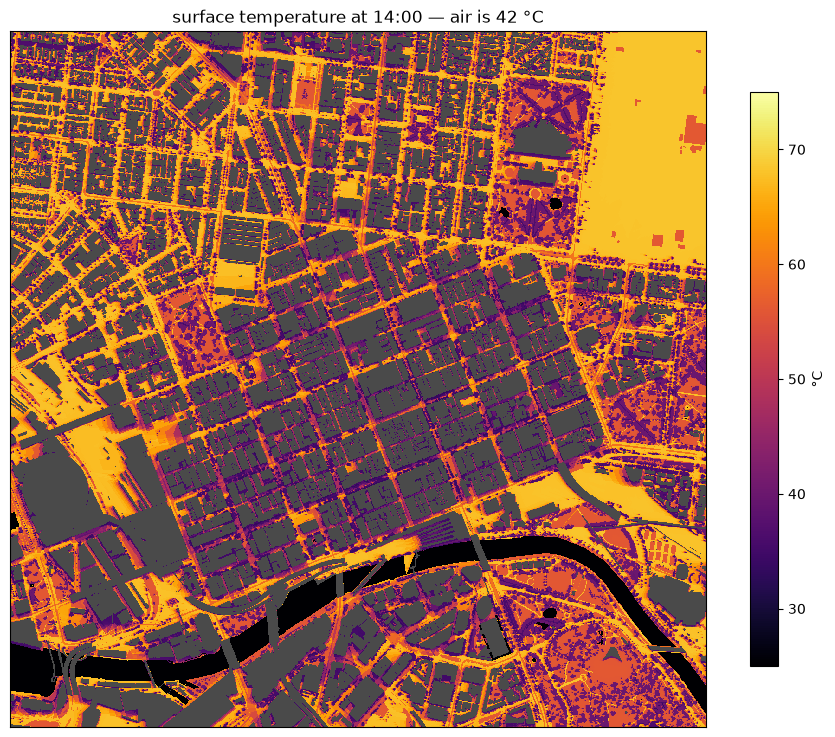

In [63]:
from matplotlib.colors import ListedColormap

MAP_HOUR = 14
lo, hi = 25, 75

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.imshow(~ground, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(~ground, tsurf[MAP_HOUR]), cmap="inferno",
               vmin=lo, vmax=hi, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"surface temperature at {MAP_HOUR}:00 — air is {w.loc[MAP_HOUR, 'temperature_2m']:.0f} °C")
fig.colorbar(im, ax=ax, shrink=0.7, label="°C")
fig.tight_layout()

## The whole grid

Everything above ran on the 1500 × 1500 crop. 07 needs the lot — 2438 × 2485, buffer
included — so the same march goes over the full rasters once and writes an hour per file.

In [64]:
shade_full = {h: np.load(f"out/rasters/shade_{h:02d}.npy") for h in HOURS}
svf_full   = np.load("out/rasters/svf_veg.npy")
mat_full   = np.load("out/rasters/material_id.npy")

for h, Ts in march_grid(shade_full, svf_full, mat_full).items():
    np.save(f"out/rasters/tsurf_{h:02d}.npy", Ts)

print(f"out/rasters/tsurf_06.npy .. tsurf_20.npy   {len(HOURS)} files at {svf_full.shape[1]} x {svf_full.shape[0]}")

out/rasters/tsurf_06.npy .. tsurf_20.npy   15 files at 2438 x 2485


### 2438 × 2485, one hour of it

Inside the CBD this is the same picture as above. Outside it, that flat apron of yellow is
05's default showing through — the council's surface records stop at the boundary, so
everything past it is asphalt because we said so, not because anyone surveyed it. The buffer
is there to get the shadows right at the edge of the crop, and that is all it is for.

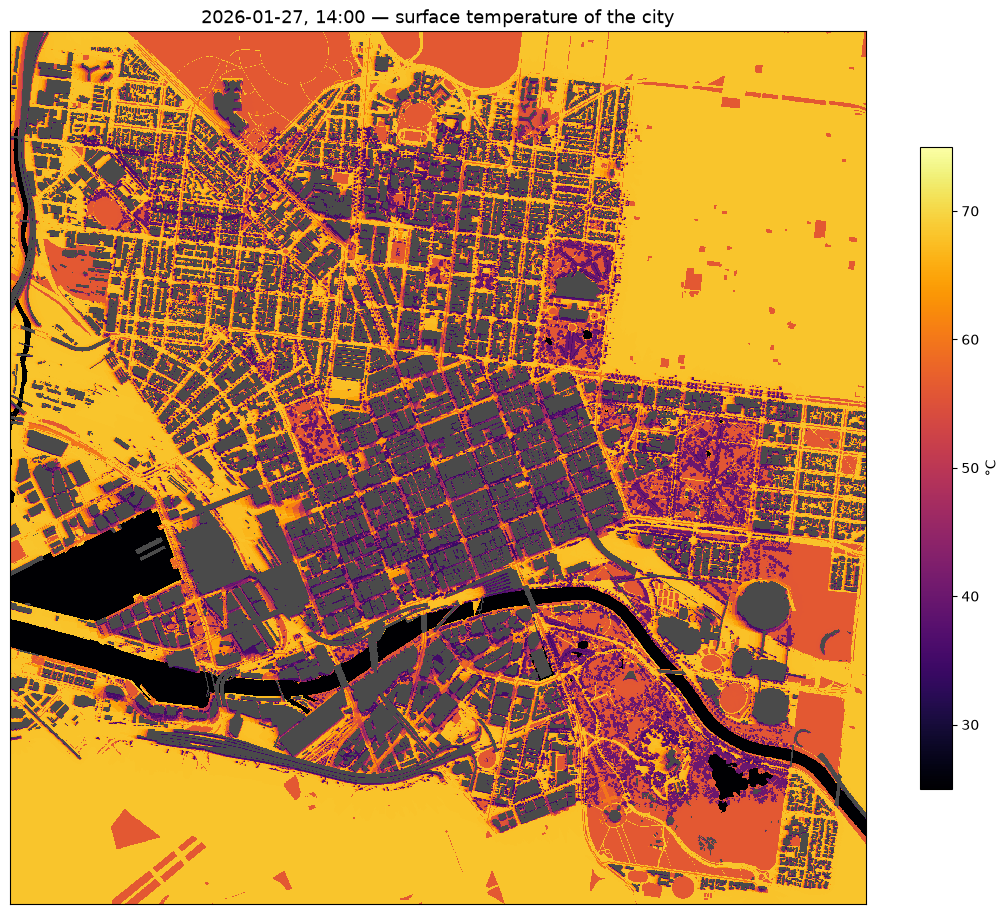

In [66]:
dsm_full = np.load("out/rasters/dsm_buildings.npy")
ground_full = dsm_full <= 0
Ts14 = np.load(f"out/rasters/tsurf_{MAP_HOUR:02d}.npy")

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(~ground_full, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(~ground_full, Ts14), cmap="inferno",
               vmin=lo, vmax=hi, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{DATE}, {MAP_HOUR}:00 — surface temperature of the city", fontsize=13)
fig.colorbar(im, ax=ax, shrink=0.6, label="°C")
fig.tight_layout()